In [18]:
import asyncio
import threading
import json
import time
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
import sklearn.cluster
import skimage
from skimage import morphology
import argparse
import matplotlib.cm as cm


In [ ]:
def whitebalance_grayworld(image):
    result = image.astype(np.float32)
    avg_r = np.mean(result[:, :, 0])
    avg_g = np.mean(result[:, :, 1])
    avg_b = np.mean(result[:, :, 2])
    avg_gray = (avg_r + avg_g + avg_b) / 3.0

    scale_r = avg_gray / avg_r if avg_r > 0 else 1.0
    scale_g = avg_gray / avg_g if avg_g > 0 else 1.0
    scale_b = avg_gray / avg_b if avg_b > 0 else 1.0

    result[:, :, 0] *= scale_r
    result[:, :, 1] *= scale_g
    result[:, :, 2] *= scale_b

    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

def whitebalance_reference(image, target=200):
    result = image.astype(np.float32)
    quantized = (image // 16) * 16  # Reduce to 16 levels per channel
    pixels = quantized.reshape(-1, 3)
    
    # Find the most common color
    unique_colors, counts = np.unique(pixels, axis=0, return_counts=True)
    most_common_idx = np.argmax(counts)
    reference_color = unique_colors[most_common_idx].astype(np.float32)
    
    print(f"Most common color (background): RGB({reference_color[0]:.0f}, {reference_color[1]:.0f}, {reference_color[2]:.0f})")
    
    # Calculate scaling factors to make this color neutral
    scale_r = target / reference_color[0] if reference_color[0] > 0 else 1.0
    scale_g = target / reference_color[1] if reference_color[1] > 0 else 1.0
    scale_b = target / reference_color[2] if reference_color[2] > 0 else 1.0
    
    print(f"Scale factors: R={scale_r:.3f}, G={scale_g:.3f}, B={scale_b:.3f}")
    
    result[:, :, 0] = result[:, :, 0] * scale_r
    result[:, :, 1] = result[:, :, 1] * scale_g
    result[:, :, 2] = result[:, :, 2] * scale_b
    result = np.clip(result, 0, 255)
    
    return result.astype(np.uint8) 

Most common color (background): RGB(0, 0, 0)
Scale factors: R=1.000, G=1.000, B=1.000

--- Reference-based method ---
Most common color (background): RGB(0, 0, 0)
Scale factors: R=1.000, G=1.000, B=1.000


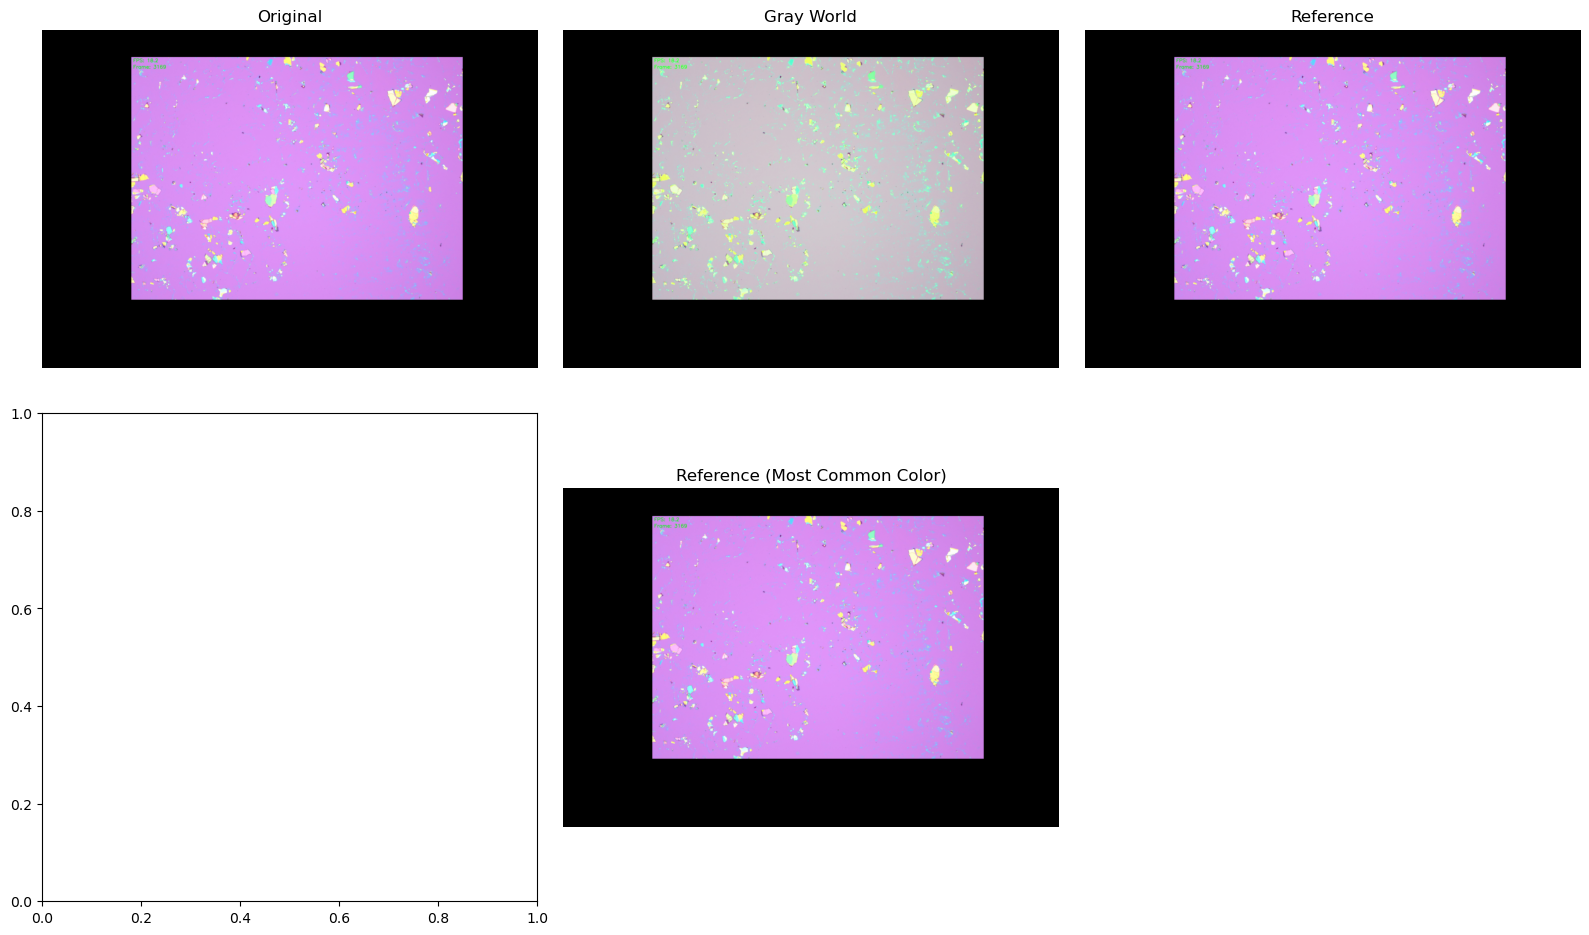

In [20]:
image = cv2.imread('image_2025-11-03_11-15-13.png', cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create comparison of all methods
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Original image
axes[0, 0].imshow(image)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Gray World method
balanced_gw = whitebalance_grayworld(image)
axes[0, 1].imshow(balanced_gw)
axes[0, 1].set_title('Gray World')
axes[0, 1].axis('off')

# Max White method
balanced_mw = whitebalance_reference(image)
axes[0, 2].imshow(balanced_mw)
axes[0, 2].set_title('Reference')
axes[0, 2].axis('off')


# Reference-based method (most common color)
print("\n--- Reference-based method ---")
balanced_ref = whitebalance_reference(image, target=200)
axes[1, 1].imshow(balanced_ref)
axes[1, 1].set_title('Reference (Most Common Color)')
axes[1, 1].axis('off')

# Empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()